In [67]:
import matplotlib.pyplot as plt
import json
from shapely.geometry import shape
from rasterio.features import rasterize
from rasterio.transform import from_origin
import rasterio
import h5py
import os
import rasterio
import numpy as np
import shutil
import requests
import time
from rasterio.windows import from_bounds
from rasterio.transform import Affine
from osgeo import gdal
from osgeo import gdalconst
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Chelsa: Environmental Factors Download and Cropping

This section downloads environmental factor data from the CHELSA dataset. The code retrieves data files for various variables (`clt`, `hurs`, `pr`, `rsds`, `sfcWind`, `tas`) for each month (01 to 12) from 2000 to 2019 using the `requests` module. The downloaded files are saved into subfolders under `/work/klok0126/Chelsa/`. After downloading, the files are cropped using GDAL, and the cropped files are saved in folders with an underscore appended (e.g. `/work/klok0126/Chelsa/clt_/`).

**File Location Example:**
- For `clt`: `/work/klok0126/Chelsa/clt_/CHELSA_clt_01_2009_V.2.1.tif`
- For `hurs`: `/work/klok0126/Chelsa/hurs_/CHELSA_hurs_06_2015_V.2.1.tif`
- For `pr`: `/work/klok0126/Chelsa/pr_/CHELSA_pr_12_2012_V.2.1.tif`
- For `rsds`: `/work/klok0126/Chelsa/rsds_/CHELSA_rsds_03_2018_V.2.1.tif`
- For `sfcWind`: `/work/klok0126/Chelsa/sfcWind_/CHELSA_sfcWind_09_2011_V.2.1.tif`
- For `tas`: `/work/klok0126/Chelsa/tas_/CHELSA_tas_07_2013_V.2.1.tif`

In [2]:
def crop_by_bounds(dir_base, dir_dst, xmin, ymin, xmax, ymax):
    if not os.path.exists(dir_dst):
        os.makedirs(dir_dst)

    for fname in os.listdir(dir_base):
        if not fname.endswith('.tif'):
            continue  # skip non-TIFF files

        src_path = os.path.join(dir_base, fname)
        dst_path = os.path.join(dir_dst, fname)

        with rasterio.open(src_path) as src:
            # 計算裁切窗口
            window = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
            window = window.round_offsets().round_lengths()
            transform = src.window_transform(window)

            # 讀取裁切範圍資料
            data = src.read(1, window=window)

            # 更新 metadata
            out_meta = src.meta.copy()
            out_meta.update({
                "height": window.height,
                "width": window.width,
                "transform": transform
            })

            with rasterio.open(dst_path, "w", **out_meta) as dst:
                dst.write(data, 1)

In [9]:
# List of environmental variables to download
# env_list = ['clt', 'hurs', 'pr', 'rsds', 'sfcWind', 'tas', 'pet', 'tasmin', 'tasmax', 'cmi', 'vpd']
env_list = ['rsds']
months = range(1, 13)
years = range(2000, 2020)

# Base directory where files will be saved
dir_base = './raw/env/Chelsa/'

# Link pattern for generating download URLs
link_pattern = dict(
    dir_base = 'https://os.zhdk.cloud.switch.ch/chelsav2/GLOBAL/monthly', 
    clt = 'clt/CHELSA_clt_[MONTH]_[YEAR]_V.2.1.tif', 
    cmi = 'cmi/CHELSA_cmi_[MONTH]_[YEAR]_V.2.1.tif', 
    hurs = 'hurs/CHELSA_hurs_[MONTH]_[YEAR]_V.2.1.tif', 
    pet = 'pet/CHELSA_pet_penman_[MONTH]_[YEAR]_V.2.1.tif', 
    pr = 'pr/CHELSA_pr_[MONTH]_[YEAR]_V.2.1.tif', 
    rsds = 'rsds/CHELSA_rsds_[YEAR]_[MONTH]_V.2.1.tif', 
    sfcWind = 'sfcWind/CHELSA_sfcWind_[MONTH]_[YEAR]_V.2.1.tif', 
    tas = 'tas/CHELSA_tas_[MONTH]_[YEAR]_V.2.1.tif', 
    tasmax = 'tasmax/CHELSA_tasmax_[MONTH]_[YEAR]_V.2.1.tif', 
    tasmin = 'tasmin/CHELSA_tasmin_[MONTH]_[YEAR]_V.2.1.tif', 
    vpd = 'vpd/CHELSA_vpd_[MONTH]_[YEAR]_V.2.1.tif'
)

# Download the CHELSA dataset files based on the combined list
for env in env_list:
    
    # Create directory for the environmental variable if it doesn't exist
    if not os.path.exists(f'{dir_base}/{env}'):
        os.makedirs(f'{dir_base}/{env}')

    for year in years:
        for month in months:
            # Replace placeholders in the URL with actual month and year values
            link_itr = f'{link_pattern[env]}'.replace('[MONTH]', f'{month:02d}').replace('[YEAR]', str(year))
            link_full = f'{link_pattern["dir_base"]}/{link_itr}'

            # Check if the file already exists
            if os.path.exists(f'{dir_base}/{link_itr}'):
                print(f"{link_itr} has already existed.")
                continue

            print(f'Accessing file: {link_itr}')
            response = requests.get(link_full)
            if response.status_code == 200:
                with open(f'{dir_base}/{link_itr}', 'wb') as file:
                    print(f"Downloaded.")
                    file.write(response.content)
                time.sleep(3)
            else:
                print(f"Cannot download link: {link_itr}.")
            response = None
            
    # Crop and delete
    # Japan
    crop_by_bounds(dir_base = f'./raw/env/Chelsa/{env}/', 
                   dir_dst = f'./raw/env/Chelsa/{env}_JAP_crop/', 
                   xmin = 122.85, ymin = 24, xmax = 154.05, ymax = 45.6)
    # Korea
    crop_by_bounds(dir_base = f'./raw/env/Chelsa/{env}/', 
                   dir_dst = f'./raw/env/Chelsa/{env}_KOR_crop/', 
                   xmin = 124.2, ymin = 33.1, xmax = 132.2, ymax = 38.7)

    # delete the original folder
    shutil.rmtree(f'./raw/env/Chelsa/{env}')
            
print("All links are downloaded.")

rsds/CHELSA_rsds_2000_01_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_02_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_03_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_04_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_05_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_06_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_07_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_08_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_09_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_10_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_11_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2000_12_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_01_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_02_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_03_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_04_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_05_V.2.1.tif has already existed.
rsds/CHELSA_rsds_2001_06_V.2.1.tif has already e

# TerraClimate

Dataset from 1958 to now [TerraClimate](https://www.climatologylab.org/terraclimate.html)
 - aet (Actual Evapotranspiration, monthly total), units = mm
 - def (Climate Water Deficit, monthly total), units = mm
 - pet (Potential evapotranspiration, monthly total), units = mm
 - ppt (Precipitation, monthly total), units = mm
 - q (Runoff, monthly total), units = mm
 - soil (Soil Moisture, total column - at end of month), units = mm
 - srad (Downward surface shortwave radiation), units = W/m2
 - swe (Snow water equivalent - at end of month), units = mm
 - tmax (Max Temperature, average for month), units = C
 - tmin (Min Temperature, average for month), units = C
 - vap (Vapor pressure, average for month), units  = kPa
 - ws (Wind speed, average for month), units = m/s
 - vpd (Vapor Pressure Deficit, average for month), units = kpa
 - PDSI (Palmer Drought Severity Index, at end of month), units = unitless

In [19]:
env_terraclimate = ['aet', 'def', 'pet', 'ppt', 'q', 'soil', 'srad', 'swe', 'tmax', 'tmin', 'vap', 'ws', 'vpd', 'PDSI']
xmin = 122.85
xmax = 154.05
ymin = 24
ymax = 45.6
time_start = '2000-01-01'
time_end = '2024-12-31'
link_template = 'http://thredds.northwestknowledge.net:8080/thredds/ncss/agg_terraclimate_[ENV]_1958_CurrentYear_GLOBE.nc?var=[ENV]&north=[YMAX]&west=[XMIN]&east=[XMAX]&south=[YMIN]&disableProjSubset=on&horizStride=1&time_start=[TIME_START]T00%3A00%3A00Z&time_end=[TIME_END]T00%3A00%3A00Z&timeStride=1&accept=netcdf'
dir_download = './raw/env/TerraClimate/agg_terraclimate_[ENV]_1958_CurrentYear_GLOBE.nc'

In [ ]:
for env in env_terraclimate:
    link_itr = link_template.replace('[ENV]', env).replace('[XMIN]', str(xmin)).replace('[XMAX]', str(xmax)).replace('[YMIN]', str(ymin)).replace('[YMAX]', str(ymax)).replace('[TIME_START]', str(time_start)).replace('[TIME_END]', str(time_end))
    print(f'Accessing file: {link_itr}')
    response = requests.get(link_itr, timeout = 180)
    if response.status_code == 200:
        with open(dir_download.replace('[ENV]', env), 'wb') as file:
            print(f"Downloaded.")
            file.write(response.content)
        time.sleep(3)
    else:
        print(f"Cannot download link: {link_itr}.")
    response = None

In [88]:
for env in env_terraclimate:
    src_nc  = gdal.Open(f'NETCDF:{dir_download.replace("[ENV]", env)}', gdalconst.GA_ReadOnly)
    operating_datetime = datetime.strptime(time_start, '%Y-%m-%d')
    if src_nc is None:
        print('Cannnot open the file.')
        continue
    else:
        band_count = src_nc.RasterCount
        print(f'There are {band_count} bands.')
        
        output_dir = f'./raw/env/TerraClimate/{env}'
        os.makedirs(output_dir, exist_ok = True)
        
        for band_idx in range(1, band_count+1):
            band = src_nc.GetRasterBand(band_idx)
            
            # Get band data
            data = band.ReadAsArray()
            
            # Set output file path
            band_name = f'TerraClimate_{env}_{operating_datetime.year}_{operating_datetime.month:02d}'
            output_tif = os.path.join(output_dir, f'{band_name}.tif')
            
            # Create tif file from GTiff driver
            driver = gdal.GetDriverByName('GTiff')
            if driver is None:
                print('No GTiff driver')
                continue
            dst_ds = driver.Create(output_tif, band.XSize, band.YSize, 1, band.DataType)
            
            # Set transformation and projection
            dst_ds.SetGeoTransform(src_nc.GetGeoTransform())
            dst_ds.SetProjection(src_nc.GetProjection())
            
            # Write band into dst_ds
            dst_ds.GetRasterBand(1).WriteArray(data)
            dst_ds.GetRasterBand(1).SetNoDataValue(band.GetNoDataValue())
            
            # Close file 
            dst_ds = None
            
            print(f'Band {band_idx} has been saved as {output_tif}')
            
            # Add one month
            operating_datetime += relativedelta(months = 1)
        
        # Close file
        src_nc = None

There are 300 bands.
Band 1 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_01.tif
Band 2 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_02.tif
Band 3 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_03.tif
Band 4 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_04.tif
Band 5 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_05.tif
Band 6 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_06.tif
Band 7 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_07.tif
Band 8 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_08.tif
Band 9 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_09.tif
Band 10 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_10.tif
Band 11 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_11.tif
Band 12 has been saved as ./raw/env/TerraClimate/aet/TerraClimate_aet_2000_12.tif
Band

# Land Cover Dataset

To download the Land Cover dataset, follow these steps:

- Visit the [ESA Land Cover](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=download) webpage.
- Sign in using your account credentials.
- Select the period **2000-2020**.
- Choose the option for the entire available region.

**File location:** `./raw/env/landcover/`

**Example file name:** 
 - `ESACCI-LC-L4-LCCS-Map-300m-P1Y-2009-v2.0.7cds.nc`
 - `ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7cds.nc` 
 - `C3S-LC-L4-LCCS-Map-300m-P1Y-2016-v2.1.1.nc`
 - `C3S-LC-L4-LCCS-Map-300m-P1Y-2020-v2.1.1.nc` 

# EVI Dataset

Follow the instructions below to download the EVI (Enhanced Vegetation Index) dataset:

- Visit [NASA’s AppEEARS](https://appeears.earthdatacloud.nasa.gov/).
- Register and sign in if you haven’t already.
- Set the spatial filter with the following coordinates:
  - Latitude from **21.80°N** to **25.40°N**
  - Longitude from **119.90°E** to **122.10°E**
- Set the start date to **01-01-2000** and the end date to **12-31-2021**.
- Choose the product **MOD13A1** and select the layer **_500m_16_days_EVI**.
- Select **GeoTiff** as the file format for download.

**File location:** `./raw/env/EVI/`

**Example file names:**
- `MOD13A1.006__500m_16_days_EVI_doy2000049_aid0001.tif`
- `MOD13A1.006__500m_16_days_EVI_doy2021353_aid0001.tif`

# Elevation Dataset

To download the Elevation dataset, simply click the link below:

[WorldClim Elevation Data](https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_30s_elev.zip)

**File location:** `./raw/env/elev/`

**Example file name:** `wc2.1_30s_elev.tif`

## 處理國界，製作extent binary raster

## Japan

In [11]:
# 使用json和shapely讀取GeoJSON
geojson_path = './raw/gadm41_JPN_0.json'
with open(geojson_path) as f:
    data = json.load(f)

shapes = [shape(feature["geometry"]) for feature in data['features']]

print(shapes[0].bounds)

(122.9332, 24.0454, 153.9869, 45.5227)


In [12]:
# 設定範圍與cell大小
xmin, ymin, xmax, ymax = 122.85, 24, 154.05, 45.6
cell_size = 0.02
width = round((xmax - xmin) / cell_size)
height = round((ymax - ymin) / cell_size)

transform = from_origin(xmin, ymax, cell_size, cell_size)

# rasterize
raster = rasterize(
    [(geom, 1) for geom in shapes],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='uint8'
)

# 輸出tif
output_path = './workspace//extent_binary_japan.tif'
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=raster.shape[0],
    width=raster.shape[1],
    count=1,
    dtype=raster.dtype,
    crs='EPSG:4326',
    transform=transform,
    nodata = 0
) as dst:
    dst.write(raster, 1)

print(f"Raster 已成功輸出至: {output_path}")
print(f'width: {width} height: {height}')

Raster 已成功輸出至: ./workspace//extent_binary_japan.tif
width: 1560 height: 1080


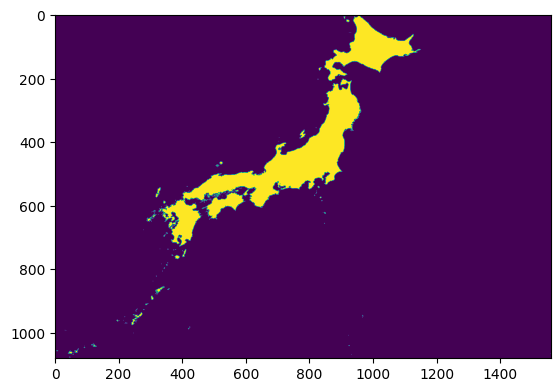

In [13]:
plt.imshow(raster)

## South Korea

In [5]:
# 使用json和shapely讀取GeoJSON
geojson_path = './raw/gadm41_KOR_0.json'
with open(geojson_path) as f:
    data = json.load(f)

shapes = [shape(feature["geometry"]) for feature in data['features']]

print(shapes[0].bounds)

(124.6097, 33.1126, 131.871, 38.6118)


In [6]:
# 設定範圍與cell大小
xmin, ymin, xmax, ymax = 124.2, 33.1, 132.2, 38.7
cell_size = 0.02
width = round((xmax - xmin) / cell_size)
height = round((ymax - ymin) / cell_size)

transform = from_origin(xmin, ymax, cell_size, cell_size)

# rasterize
raster = rasterize(
    [(geom, 1) for geom in shapes],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='uint8'
)

# 輸出tif
output_path = './workspace//extent_binary_korea.tif'
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=raster.shape[0],
    width=raster.shape[1],
    count=1,
    dtype=raster.dtype,
    crs='EPSG:4326',
    transform=transform,
) as dst:
    dst.write(raster, 1)

print(f"Raster 已成功輸出至: {output_path}")
print(f'width: {width} height: {height}')

Raster 已成功輸出至: ./workspace//extent_binary_korea.tif
width: 400 height: 280


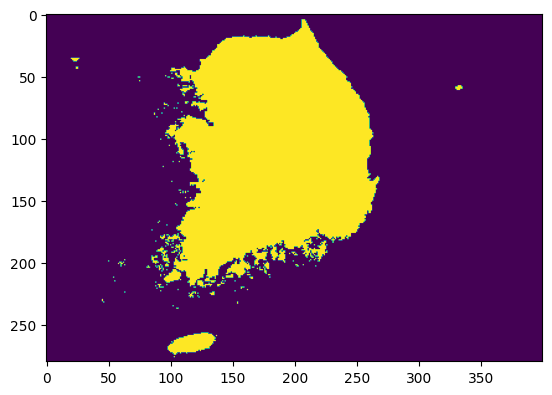

In [7]:
plt.imshow(raster)